#Early Stopping


# <Topic Name>

## Pre-requisites
To start this lession on *early stopping* **all students must be aware** of the following concepts:
* Forward and Backward Propagation in ANN
* Optimization
* Introduction to Regularisation



## Learning Objectives
By the end of this lesson, **all learners** will be able to:

<!-- [ C=Condition + A=Actor + B=Behaviour + D=Degree ]  -->

<!-- [Remember] -->

<!-- [Understand] -->
* Summarize the concept of early stopping
<!-- [Apply] -->
* Implement early stopping in Multi Layer Perceptron (MLP)
<!-- [Analyze] -->
* Examine testing accuracy with and without the application of early stopping
<!-- [Evaluate] -->

<!-- [Create]  -->



##  Introduction to Early Stopping

### How does early stopping helps in regularization?

When we are using a sufficiently complex model to train on a given data, the loss on train dataset and validation dataset decreases as we train the model. But as we keep training the model for larger number of epochs a point will be reached when **the error on train dataset keeps decreasing but error on validation dataset starts to increase (overfitting) giving a U-shaped validation set performance** curve as shown in following figure. If we train the model upto this point then we can obtain model with least validation error and hopefully least error on test data as well.

<center>
<figure>


<p>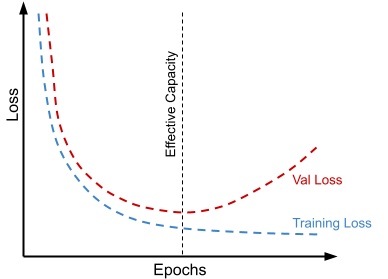</p>
<figcaption align="center">Figure 1: Validation and Training loss Vs Training Epochs  </figcaption>
</figure>
</center>

Early stopping is the **most common and simplest approach to regularising a model**. What we can do is store a copy of the model every time improvement is seen on error on validation dataset and after termination of the model training algorithm, return these parameters instead of the latest ones. We can also **terminate the training process when there is no longer sufficient improvement in parameters after certain iterations of achieving best validation error.** The number of iterations or **patience (say p)** to observe after obtaining best validation error varies depending on the model. Sometimes **plateau** might occur in validation loss. It is better to increase value of p in such case. But in some cases value of p can be smaller than 10.



<center>
<figure>


<p>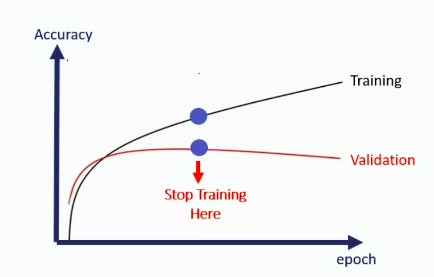</p>
<figcaption align="center">Figure 2: Number of Epochs Vs Accuracy in Validation and Training Set  </figcaption>
</figure>
</center>


### When to apply early-stopping ?
There are some parameters that can be imployed to not give model the chances to overfit by stopping at a certain epoch:

1. Monitor testing accuracy: Constantly monitor testing accuracy, loss Vs number of epochs.
2. Set off trigger points during training: While constantly monitoring the testing (validation) performance of the model, once it reaches a platue state, and before the loss starts increasing the training of the model should be cut off. It is to ensure theat the model doesn't overfit on noises affecting the overall performance.
3. Saving the model: The model can be preferred to save when the testing accuracy at a certain epoch is better than its prior epoch.

Note that when using early stopping, new hyperparameter is introduced: number of training steps. The additional cost that arises is the need to maintan copy of the best parameters. In contrast to using weight-decay, early stopping does not require addition of penalty terms to the cost function and computation of gradients of additional terms. It also reduces computational cost of the training procedure by limiting number of training iterations.






The concept of early stopping is the fundamental method of preventing overfitting in a model. There are very little reasons to not use early stopping when training a neural networks. Hence, **the techniques of early stopping should be used universally.**

In neural networks, we want to optimize the cost function and not overfit. We want to find weights and biases so that cost function is as small as possible(in case of minimization problem). And it's completely separate task to not overfit(to reduce variance). This could be taken as the only downside of the early stopping.


##  Implementation of Early Stopping using Tensorflow

Let us implement the concept of early stopping and visualize how it prevents a model from getting overfitted:


### Implementation of Neural Network for classification **without Early Stopping**


In [ ]:
#Importing make_moons to prepare dataset
from sklearn.datasets import make_moons

#Generating 2D classification data using Sklearn
X,y=make_moons(n_samples=500, noise=0.3, random_state=1)

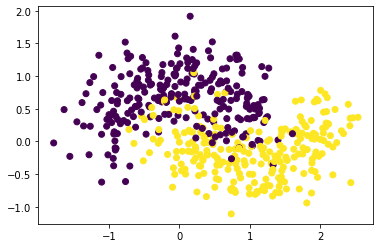

In [ ]:
#Visualize the data
from matplotlib import pyplot as plt

plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
# Importing necessary tensorflow libraries
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


# split into train and test with split ratio of 70:30
n_train = 400
trainX, testX = X[:n_train, :], X[n_train:, :]
trainy, testy = y[:n_train], y[n_train:]

# Model Definition
model = Sequential()
model.add(Dense(800, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# fit model
history = model.fit(trainX, trainy, validation_data=(testX, testy), epochs=1500, verbose=0)

# evaluate the model
_, train_acc = model.evaluate(trainX, trainy, verbose=0)
_, test_acc = model.evaluate(testX, testy, verbose=0)

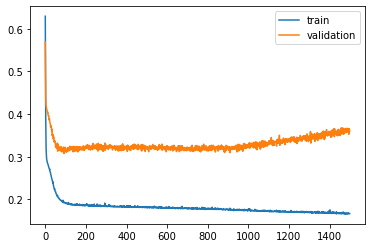

In [ ]:
# plot training history using matplotlib
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()

### Implementation of Neural Network for Classification **With Early Stopping**


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Model generation
model = Sequential()
model.add(Dense(500, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# simple early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1,patience=20)

In [ ]:
# fit model
history = model.fit(trainX, trainy, validation_data=(testX, testy), epochs=1500, verbose=0, callbacks=[es])
# evaluate the model
_, train_acc = model.evaluate(trainX, trainy, verbose=0)
_, test_acc = model.evaluate(testX, testy, verbose=0)

Epoch 00137: early stopping


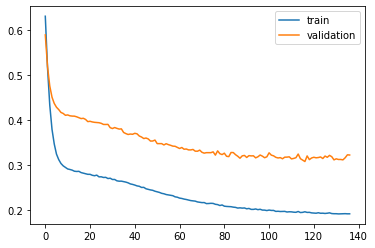

In [ ]:
# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()

##  Implementation of Early Stopping using Pytorch

Let us implement the concept of early stopping and visualize how it prevents a model from getting overfitted:


In [ ]:
# Defining Early stopping
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
            trace_func (function): trace print function.
                            Default: print
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.trace_func = trace_func

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [ ]:
# Importing necessary libraries
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.nn import functional as F
# import EarlyStopping
import numpy as np

from sklearn.model_selection import train_test_split

# define the batch size
batch_size = 400

# split into train and test with split ratio of 70:30
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.3, random_state=42)

X_train_t = torch.from_numpy(X_train).to(torch.float32)
y_train_t = torch.from_numpy(y_train).to(torch.float32)
X_val_t = torch.from_numpy(X_val).to(torch.float32)
y_val_t = torch.from_numpy(y_val).to(torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Define model
model = nn.Sequential(
    nn.Linear(2, 256),
    nn.Linear(256, 1)
).to(device)

# specify loss function
lossfunc = nn.BCEWithLogitsLoss()

# specify optimizer
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
def train_model(model, batch_size, patience, n_epochs = 1500):

    # to track the training loss as the model trains
    train_losses = []
    # to track the validation loss as the model trains
    valid_losses = []
    # to track the average training loss per epoch as the model trains
    avg_train_losses = []
    # to track the average validation loss per epoch as the model trains
    avg_valid_losses = []

    # initialize the early_stopping object
    if isinstance(patience, int):
      early_stopping = EarlyStopping(patience=patience, verbose=True)

    for epoch in range(1, n_epochs + 1):

        ###################
        # train the model #
        ###################
        model.train() # prep model for training
        for data, target in train_dataloader:
            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            data = data.to(device)
            target = target.to(device)

            output = model(data)

            output = torch.squeeze(output, 1)

            loss = lossfunc(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # perform a single optimization step (parameter update)
            optimizer.step()
            # record training loss
            train_losses.append(loss.item())

        ######################
        # validate the model #
        ######################
        model.eval() # prep model for evaluation
        for data, target in val_dataloader:
            # forward pass: compute predicted outputs by passing inputs to the model
            data = data.to(device)
            target = target.to(device)
            output = model(data)

            output = torch.squeeze(output, 1)
            # calculate the loss
            loss = lossfunc(output, target)

            # record validation loss
            valid_losses.append(loss.item())

        # print training/validation statistics
        # calculate average loss over an epoch
        train_loss = np.average(train_losses)
        valid_loss = np.average(valid_losses)
        avg_train_losses.append(train_loss)
        avg_valid_losses.append(valid_loss)

        epoch_len = len(str(n_epochs))

        print_msg = (f'[{epoch:>{epoch_len}}/{n_epochs:>{epoch_len}}] ' +
                     f'train_loss: {train_loss:.5f} ' +
                     f'valid_loss: {valid_loss:.5f}')

        print(print_msg)

        # clear lists to track next epoch
        train_losses = []
        valid_losses = []

        # early_stopping needs the validation loss to check if it has decresed,
        # and if it has, it will make a checkpoint of the current model
        if isinstance(patience, int):
          early_stopping(valid_loss, model)

          if early_stopping.early_stop:
              print("Early stopping")
              break

    return  model, avg_train_losses, avg_valid_losses

### Training of Neural Network for classification **without Early Stopping**


In [ ]:
_, train_losses, val_losses = train_model(model, batch_size, patience= None)

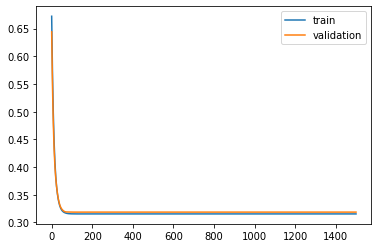

In [ ]:
# plot training history using matplotlib
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.legend()
plt.show()

### Training of Neural Network for classification **With Early Stopping**


In [ ]:
_, train_losses, val_losses = train_model(model, batch_size, patience= 20)

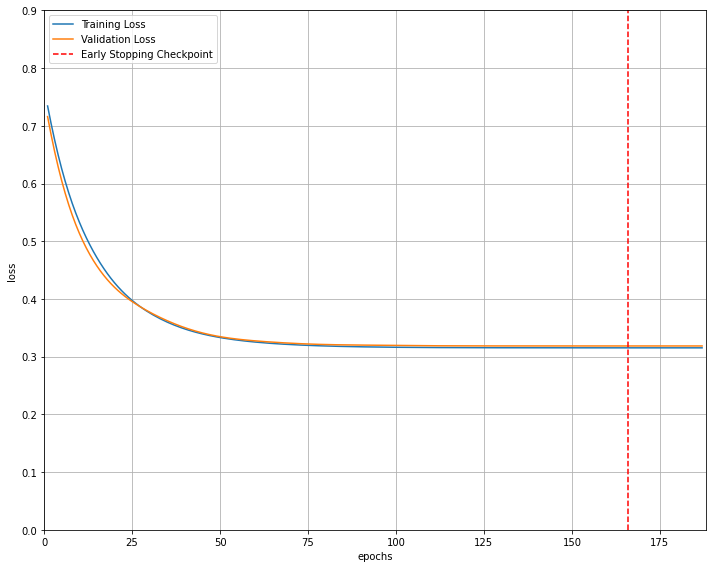

In [ ]:
# visualize the loss as the network trained
fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(train_losses)+1),train_losses, label='Training Loss')
plt.plot(range(1,len(val_losses)+1),val_losses,label='Validation Loss')

# find position of lowest validation loss
minposs = val_losses.index(min(val_losses))+1
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.ylim(0, 0.9) # consistent scale
plt.xlim(0, len(train_losses)+1) # consistent scale
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
fig.savefig('loss_plot.png', bbox_inches='tight')

As we can see comparing the two figures(initial one reaching 1400+ epochs and second one stopping at 170 ), the validation loss didnt have the chance to keep on increasing i.e. model had not chances to overfit.


## Key Takeaways
* Early Stopping is the fundamental method to prevent the model from overfitting
* It should be implemented universally
* We terminate the training process when there is no longer sufficient improvement in parameters after certain iterations of achieving best validation error. Such termination is called early stopping


## Resources
* Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learning. Cambridge, Massachusetts: The MIT press. Retrieved from [URL](https://books.google.com.np/books?hl=en&lr=&id=omivDQAAQBAJ&oi=fnd&pg=PR5&dq=Goodfellow,+Ian,+Yoshua+Bengio,+and+Aaron+Courville.+Deep+learning.+MIT+press,+2016.&ots=MMV4aooITV&sig=XJ8bjwtHmlT-OEly6O_kw0D3lfA&redir_esc=y#v=onepage&q=Goodfellow%2C%20Ian%2C%20Yoshua%20Bengio%2C%20and%20Aaron%20Courville.%20Deep%20learning.%20MIT%20press%2C%202016.&f=false)
